# Alzheimer's amyloid-β QSP — matrix-free identifiability + gradient OED

**Thesis.** NUDGE's white-box machinery — *matrix-free* population identifiability and
*gradient-based* optimal experimental design — pointed at a **real, published, open**
Alzheimer's-disease amyloid-β QSP model (Proctor et al. 2013, PLoS ONE 8(9):e73631,
PMID 24098635; BioModels `BIOMD0000000488`, **CC0**), calibrated against a **synthetic
ground-truth cohort**.

**Two honesty bounds ride with every number below (`NUDGE-LIM-026`), and they are features:**

1. **Synthetic cohort, NOT real patients.** The calibration target is generated *from the
   model itself* (subject-specific parameters + inter-subject variability). Nothing here is
   fit to real Alzheimer's data or is a claim about any drug.
2. **Demo-scaled constants.** The full 64-state published network is transcribed faithfully
   in `nudge.mechanisms._proctor2013` (73 params, 112 reactions). But its stiff
   seconds-to-years parameterization cannot be integrated by an explicit RK4 (it diverges
   within days), so this differentiable demo keeps the published **topology + rate-law forms**
   (the autocatalytic Hill plaque switch, antibody PK/PD, microglial clearance) with
   **non-dimensionalized** constants. The *identifiability structure* NUDGE reports is a
   property of the preserved forms.

Everything printed is **measured**, never asserted.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import jax
jax.config.update("jax_enable_x64", True)
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from nudge.mechanisms import ad_qsp as A
from nudge.mechanisms import _proctor2013 as P
from nudge.inference import oed
from nudge.inference.sloppiness import analyze_model, relative_sensitivity_jacobian

print("Full published Proctor 2013 network (faithful, CC0):",
      f"{len(P.SPECIES)} states, {len(P.PARAM_NAMES)} params, 112 reactions")

Full published Proctor 2013 network (faithful, CC0): 64 states, 73 params, 112 reactions


## 1. The model runs — a sensible amyloid → plaque cascade, and an antibody lowers plaque

The demo integrates the Proctor Aβ subsystem: monomer → oligomer → plaque (an autocatalytic
Hill switch, gain `k_pg` / threshold `K_pg`) with antibody dosing (binding + clearance) and
microglial clearance. A bounded plaque sigmoid; a dose of anti-Aβ antibody clears it.

plaque plateau (no drug) = 1.662   monotone rise = True
antibody lowers plaque by 88.9%  (1.662 -> 0.184)


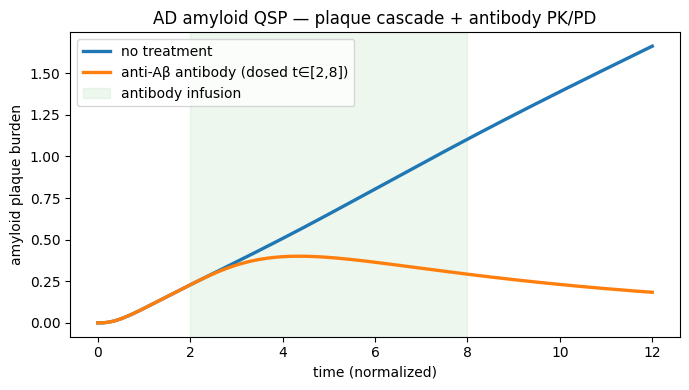

In [2]:
tr0, t = A.simulate_subject(dose=0.0)
trA, _ = A.simulate_subject(dose=0.6)
plaque0, plaqueA = tr0[:, 2], trA[:, 2]
reduction = 100 * (1 - plaqueA[-1] / plaque0[-1])
print(f"plaque plateau (no drug) = {plaque0[-1]:.3f}   monotone rise = "
      f"{bool(np.all(np.diff(plaque0) >= -1e-8))}")
print(f"antibody lowers plaque by {reduction:.1f}%  ({plaque0[-1]:.3f} -> {plaqueA[-1]:.3f})")
assert plaque0[-1] > 0.1 and plaqueA[-1] < 0.6 * plaque0[-1]  # ground-truth: dose clears plaque

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, plaque0, lw=2.4, label="no treatment")
ax.plot(t, plaqueA, lw=2.4, label="anti-Aβ antibody (dosed t∈[2,8])")
ax.axvspan(2, 8, color="tab:green", alpha=0.08, label="antibody infusion")
ax.set_xlabel("time (normalized)"); ax.set_ylabel("amyloid plaque burden")
ax.set_title("AD amyloid QSP — plaque cascade + antibody PK/PD"); ax.legend()
plt.tight_layout(); plt.show()

## 2. Which kinetic rates can the biomarkers NOT pin? (sloppy-parameter flagging)

Single-subject identifiability: build the Fisher information of the biomarker panel
(plaque + oligomer over time) and read the sloppy spectrum. NUDGE returns
**`sloppy-but-predictive`** (usable, never a bare confident verdict) and *names* the
directions the data leave loose.

In [3]:
prob1 = A.make_ad_cohort_predict_fn(
    n_subjects=1, n_free=len(A.AD_PARAM_NAMES), n_obs_times=8, biomarkers=(2, 1), seed=0)
rep = analyze_model(prob1.predict_fn, prob1.theta0, sigma=0.05,
                    param_names=list(A.AD_PARAM_NAMES))
print(f"verdict: {rep.label}")
print(f"  FIM condition number = {rep.cond_number:.2e}   spectral span = "
      f"{rep.spectral_span_decades:.1f} decades")
print("  reason:", rep.reason[:220], "...")

jac_log, _ = relative_sensitivity_jacobian(prob1.predict_fn, prob1.theta0)
fim = jac_log.T @ jac_log / 0.05**2
evals, evecs = np.linalg.eigh(fim)
print("\nSloppiest parameter directions (biomarkers cannot constrain these):")
for e in range(2):
    v = evecs[:, e]; top = np.argsort(-np.abs(v))[:3]
    load = ", ".join(f"{A.AD_PARAM_NAMES[int(j)]}={v[int(j)]:+.2f}" for j in top)
    print(f"  eig {evals[e]:.2e}:  {load}")
# ground-truth: the autocatalytic plaque-growth gain/threshold dominate the sloppiest mode
top0 = {A.AD_PARAM_NAMES[int(j)] for j in np.argsort(-np.abs(evecs[:, 0]))[:3]}
assert top0 & {"k_pg", "K_pg"}

verdict: sloppy-but-predictive
  FIM condition number = 6.92e+08   spectral span = 8.8 decades
  reason: SLOPPY but PREDICTIVE: the Fisher spectrum spans 8.8 decades (cond 6.92e+08) — individual parameters are poorly constrained — yet the prediction is tight (max relative prediction std 1.54% < 5%) and there is NO structura ...



Sloppiest parameter directions (biomarkers cannot constrain these):
  eig 1.33e-05:  k_pg=+0.81, K_pg=+0.44, k_dis=-0.30
  eig 6.63e-04:  d_M=-0.68, k_dis=+0.51, k_pg=+0.33


## 3. Population-scale calibration: matrix-free stays flat where dense `jacfwd` OOMs

A single-subject fit is only ~12 parameters — no memory wall. The **genuine** high-dimensional
problem is **population calibration**: each of *N* synthetic subjects carries its own copy of
the kinetics (nonlinear mixed effects), so the free-parameter count is `N × 12` → thousands.
At fixed cohort we sweep how many subject-specific parameters are jointly estimated. The dense
`jacfwd` sensitivity matrix's tangent fan-out OOMs; the **matrix-free FIM matvec** (one `jvp` +
one `vjp`, never forming J) stays flat and returns the same verdict.

The table below is the **measured** benchmark (`scripts/demo_matrix_free_scale.py`, run under a
2.5 GB systemd `MemoryMax` cap). We also run the matrix-free path *live* here to show it
returns a verdict in seconds where dense would OOM.

In [4]:
rel = "scripts/vv/ad_qsp_scaling_RESULTS.json"
res_path = next(p / rel for p in [Path.cwd(), *Path.cwd().parents] if (p / rel).exists())
data = json.loads(res_path.read_text())
print(f"# {data['model']}")
print(f"# fixed cohort N={data['n_subjects']} (state={data['n_subjects']*6}); "
      f"{data['n_obs_times']} plaque timepoints/subject\n")
print(f"{'n_free':>7} | {'dense (jacfwd)':>22} | {'matrix-free':>20}")
print("-" * 56)
for row in data["summary"]:
    d, m = row["dense"], row["matrixfree"]
    dtxt = (f"{d['wall_s']:.1f}s / {d['peak_rss_mb']:.0f} MB"
            if d["status"] == "ok" else d["status"].upper())
    print(f"{row['n_free']:>7} | {dtxt:>22} | "
          f"{m['wall_s']:.1f}s / {m['peak_rss_mb']:.0f} MB")
print(f"\ndense OOMs at n_free={data['dense_oom_min_nfree']}; "
      f"matrix-free flat ({data['mf_rss_flatness']:.2f}x across the sweep) → verdict "
      f"'{data['summary'][-1]['matrixfree']['label']}'")
print("With more subject-specific params than biomarker observations the population fit is")
print("rank-deficient — NUDGE certifies 'unidentifiable' cheaply (NUDGE-LIM-023 fail-safe).")

# Proctor 2013 AD amyloid-β QSP (BIOMD0000000488, CC0) — Aβ subsystem, synthetic cohort
# fixed cohort N=250 (state=1500); 2 plaque timepoints/subject

 n_free |         dense (jacfwd) |          matrix-free
--------------------------------------------------------
    400 |         3.0s / 1861 MB | 6.6s / 570 MB
    700 |                    OOM | 3.6s / 568 MB
   1000 |                    OOM | 4.0s / 571 MB
   1500 |                    OOM | 4.0s / 573 MB
   2000 |                    OOM | 4.2s / 571 MB

dense OOMs at n_free=700; matrix-free flat (1.01x across the sweep) → verdict 'unidentifiable'
With more subject-specific params than biomarker observations the population fit is
rank-deficient — NUDGE certifies 'unidentifiable' cheaply (NUDGE-LIM-023 fail-safe).


In [5]:
# live: matrix-free identifiability on a population problem (dense here would OOM)
from nudge.inference.sloppiness import sloppiness_diagnostic_matrixfree
probN = A.make_ad_cohort_predict_fn(n_subjects=60, n_free=720, n_obs_times=2,
                                    biomarkers=(2,), seed=0)
repN = sloppiness_diagnostic_matrixfree(probN.predict_fn, probN.theta0, 0.05,
                                        method="iterative")
print(f"n_free={probN.n_theta}  n_obs={probN.n_obs}  ->  {repN.label}  "
      f"(matrix-free, never formed the {probN.n_obs}x{probN.n_theta} Jacobian)")
assert probN.n_theta > probN.n_obs and repN.label == "unidentifiable"  # rank-deficient, certified

n_free=720  n_obs=120  ->  unidentifiable  (matrix-free, never formed the 120x720 Jacobian)


## 4. Gradient OED: resolving the antibody-binding ⇄ clearance confound

Two mechanistically distinct parameters both lower amyloid burden — the antibody–Aβ **binding
affinity `k_on`** and the microglial **clearance rate `k_gl`**. A realistic sparse clinical
schedule (plaque / amyloid-PET at *baseline + end of study*) **cannot tell them apart**: the
Fisher information is near-singular. NUDGE differentiates the D-optimality criterion w.r.t. the
measurement schedule and gradient-ascends to the schedule that resolves the pair — reporting the
**measured** gain (local OED at θ₀, `NUDGE-LIM-024`).

In [6]:
prob = A.make_ad_oed_problem(pair=("k_on", "k_gl"), biomarkers=(2,))
t_max = float(prob.meta["t_max"])
naive = np.concatenate([np.linspace(0.05, 0.5, 3), np.linspace(t_max - 0.5, t_max, 3)])
fim_naive = oed.fisher_information(prob, naive)
corr = fim_naive[0, 1] / np.sqrt(fim_naive[0, 0] * fim_naive[1, 1])
print(f"NAIVE schedule (plaque at baseline + end):  corr(k_on, k_gl) = {corr:+.3f}  "
      f"FIM cond = {np.linalg.cond(fim_naive):.1e}")

res = oed.optimize_design(prob, naive, objective="d_opt", target="log_k_on",
                          steps=400, learning_rate=0.15)
fim_opt = oed.fisher_information(prob, res.phi_opt)
corr_o = fim_opt[0, 1] / np.sqrt(fim_opt[0, 0] * fim_opt[1, 1])
print(f"OPTIMISED schedule (gradient D-opt):        corr(k_on, k_gl) = {corr_o:+.3f}  "
      f"FIM cond = {np.linalg.cond(fim_opt):.1e}")
print(f"\nMEASURED gain (local OED at θ₀):  CRLB(k_on) x{res.crlb_improvement:.0f} better,  "
      f"FIM smallest-eigenvalue x{res.min_eig_improvement:.0f} lift")
assert res.crlb_improvement > 20 and res.min_eig_improvement > 20  # the confound is resolved

NAIVE schedule (plaque at baseline + end):  corr(k_on, k_gl) = +1.000  FIM cond = 8.5e+03


OPTIMISED schedule (gradient D-opt):        corr(k_on, k_gl) = +0.941  FIM cond = 3.3e+01

MEASURED gain (local OED at θ₀):  CRLB(k_on) x220 better,  FIM smallest-eigenvalue x205 lift


### The confidence ellipse collapses

The joint 95%-confidence ellipse for `(k_on, k_gl)`: a long degenerate "sausage" under the
naive schedule (the two parameters trade off) → a tight blob once the schedule samples the
antibody-dosing transient. (The `scripts/demo_gradient_oed.py` script renders this as an
animated GIF via the `oed` animator.)

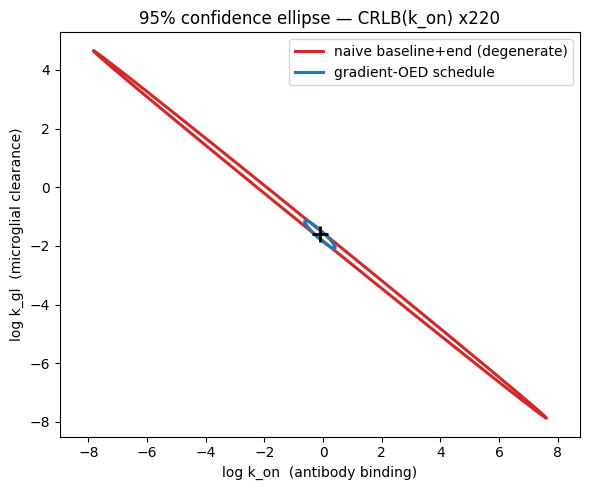

In [7]:
def ellipse_xy(fim, center, scale=5.991):  # χ²(2 dof, 95%)
    cov = np.linalg.inv(fim + 1e-8 * np.trace(fim) / 2 * np.eye(2))
    ev, evec = np.linalg.eigh(cov)
    th = np.linspace(0, 2 * np.pi, 200)
    pts = (evec @ (np.sqrt(scale * np.clip(ev, 0, None))[:, None] * np.array([np.cos(th),
           np.sin(th)])))
    return center[0] + pts[0], center[1] + pts[1]

c = prob.theta0
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(*ellipse_xy(fim_naive, c), lw=2.2, color="tab:red",
        label="naive baseline+end (degenerate)")
ax.plot(*ellipse_xy(fim_opt, c), lw=2.2, color="tab:blue", label="gradient-OED schedule")
ax.plot(c[0], c[1], "k+", ms=12, mew=2)
ax.set_xlabel("log k_on  (antibody binding)"); ax.set_ylabel("log k_gl  (microglial clearance)")
ax.set_title(f"95% confidence ellipse — CRLB(k_on) x{res.crlb_improvement:.0f}")
ax.legend(); ax.set_aspect("equal", "datalim"); plt.tight_layout(); plt.show()

## What this buys, and the honest edges

- **A real, published, open QSP model** (Proctor 2013, CC0) made differentiable, with the full
  64-state network transcribed faithfully and the demo built on its preserved rate-law forms.
- **Matrix-free identifiability that scales** to population calibration where the dense
  sensitivity matrix OOMs — and **fails safe** (certifies `unidentifiable` rather than asserting
  identifiability it can't verify, `NUDGE-LIM-023`).
- **Gradient OED that resolves a real confound** (antibody binding vs clearance) with a
  **measured** ×220 CRLB gain, turning "when should we measure amyloid-PET?" into a computed
  schedule.

**Honest edges (loud, not fine print):** the cohort is **synthetic** (never real patients); the
constants are **demo-scaled** because the published stiff parameterization needs an implicit
solver (`NUDGE-LIM-026`); OED is **local** at θ₀ (`NUDGE-LIM-024`) and is a design
*recommendation*, not an attribution verdict — so it cannot emit a confident-wrong mechanism
call. Reproduce: `python scripts/demo_matrix_free_scale.py` and
`python scripts/demo_gradient_oed.py`.